In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm

In [2]:
os.makedirs("model_checkpoints", exist_ok=True)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
class HandSignDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the hand sign image folders
            transform (callable, optional): Optional transform to be applied on a sample
        """
        self.root_dir = root_dir
        self.transform = transform
        
        # Dynamically determine classes by checking which folders contain images
        self.classes = []
        for folder_name in sorted(os.listdir(root_dir)):
            folder_path = os.path.join(root_dir, folder_name)
            if os.path.isdir(folder_path):
                # Check if the folder contains any images
                has_images = any(file.endswith(('.jpg', '.jpeg', '.png')) 
                                for file in os.listdir(folder_path))
                if has_images:
                    self.classes.append(folder_name)
        
        # Create class to index mapping
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        print(f"Found {len(self.classes)} classes: {self.classes}")
        
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                if img_name.endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_dir, img_name)
                    self.samples.append((img_path, self.class_to_idx[class_name]))
        
        print(f"Found {len(self.samples)} images in total")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [5]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(45),
        transforms.RandomAffine(
            degrees=0, 
            translate=(0.1, 0.1),  # Random translation
            scale=(0.9, 1.1),      # Random scaling
            shear=10               # Random shearing
        ),
        transforms.ColorJitter(
            brightness=0.4,        # More aggressive brightness
            contrast=0.4,          # More aggressive contrast
            saturation=0.4,        # Added saturation variation
            hue=0.1                # Added hue variation
        ),
        # Occasionally add blur
        transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
        # Grayscale occasionally to simulate poor color conditions
        transforms.RandomGrayscale(p=0.05),
        transforms.ToTensor(),
        # Add random noise occasionally
        transforms.RandomApply([
            transforms.Lambda(lambda x: x + 0.05 * torch.randn_like(x))
        ], p=0.3),
        # Normalize as before
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [6]:
def train_val_split(dataset, val_ratio=0.2):
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    return train_dataset, val_dataset

In [7]:
data_dir = "data"  # Change this to your data directory
full_dataset = HandSignDataset(data_dir, transform=data_transforms['train'])

Found 6 classes: ['1', '2', '3', '4', '5', '6']
Found 610 images in total


In [8]:
num_classes = len(full_dataset.classes)
if num_classes == 0:
    raise ValueError("No classes found in the data directory. Make sure your folders contain images.")

# Check if there are enough samples
if len(full_dataset) < 20:
    print(f"Warning: Only {len(full_dataset)} samples found. Consider collecting more data.")

In [9]:
train_dataset, val_dataset = train_val_split(full_dataset)
train_dataset.dataset.transform = data_transforms['train']
val_dataset.dataset.transform = data_transforms['val']

In [10]:
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [11]:
def load_model(num_classes):
    # Load pre-trained ResNet-18
    model = models.resnet18(weights='IMAGENET1K_V1')
    
    # Freeze early layers
    for param in list(model.parameters())[:-8]:  # Freeze all but the last 2 blocks
        param.requires_grad = False
    
    # Replace the final fully connected layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, num_classes)
    )
    
    return model

In [12]:
model = load_model(num_classes=num_classes)
model = model.to(device)

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.fc.parameters(), 'lr': 0.001},
    {'params': list(model.layer4.parameters()), 'lr': 0.0001}
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

In [14]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, patience=5, delta=0.001):  
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    
    # Early stopping variables
    early_stopping_counter = 0
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):       
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            
            running_loss = 0.0
            running_corrects = 0
            
            # Create tqdm progress bar with total iterations
            total_iterations = len(dataloaders[phase])
            progress_bar = tqdm(dataloaders[phase], total=total_iterations, 
                               desc=f'{phase.capitalize()}')
            
            # Iterate over data
            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                batch_loss = loss.item()
                batch_acc = torch.sum(preds == labels.data).double() / inputs.size(0)
                running_loss += batch_loss * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Update progress bar with current batch stats
                progress_bar.set_postfix({
                    'loss': f'{batch_loss:.4f}',
                    'acc': f'{batch_acc:.4f}'
                })
            
            # Calculate epoch statistics
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                # Update learning rate based on validation loss
                scheduler.step(epoch_loss)
                
                # Early stopping check
                if epoch_loss < best_val_loss - delta:
                    best_val_loss = epoch_loss
                    early_stopping_counter = 0
                    # Save the best model
                    if epoch_acc > best_acc:
                        best_acc = epoch_acc
                        torch.save(model.state_dict(), 'model_checkpoints/best_model.pth')
                        print(f'Saved new best model with accuracy: {best_acc:.4f}')
                else:
                    early_stopping_counter += 1
                    print(f'EarlyStopping counter: {early_stopping_counter} out of {patience}')
                    if early_stopping_counter >= patience:
                        print(f'Early stopping triggered after {epoch+1} epochs')
                        print(f'Best val Acc: {best_acc:.4f}')
                        # Load best model weights
                        model.load_state_dict(torch.load('model_checkpoints/best_model.pth'))
                        return model, history
        
        print()
    
    print(f'Training completed for all {num_epochs} epochs')
    print(f'Best val Acc: {best_acc:.4f}')
    
    # Load best model weights
    model.load_state_dict(torch.load('model_checkpoints/best_model.pth'))
    return model, history

In [15]:
dataloaders = {'train': train_loader, 'val': val_loader}
num_epochs = 30

In [16]:
model, history = train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=num_epochs, patience=5, delta=0.001)

Val: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, loss=1.6634, acc=0.2377]


Saved new best model with accuracy: 0.2377



Val: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, loss=1.4631, acc=0.3115]


Saved new best model with accuracy: 0.3115



Val: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, loss=1.1821, acc=0.5656]


...

EarlyStopping counter: 3 out of 5



Val: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, loss=0.0758, acc=0.9836]


EarlyStopping counter: 4 out of 5



Val: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, loss=0.0930, acc=0.9672]

EarlyStopping counter: 5 out of 5
Early stopping triggered after 28 epochs
Best val Acc: 0.9918


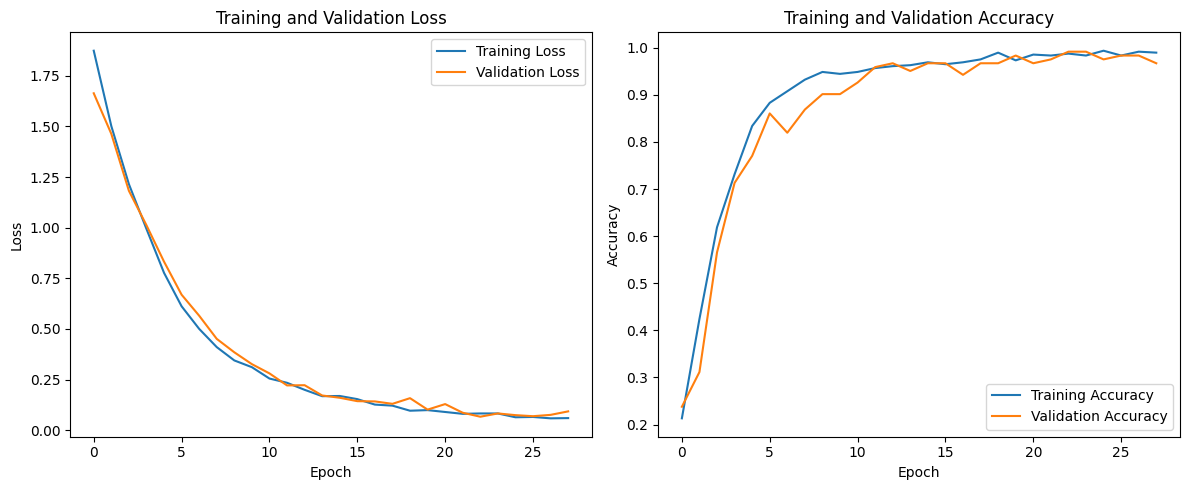

In [17]:
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

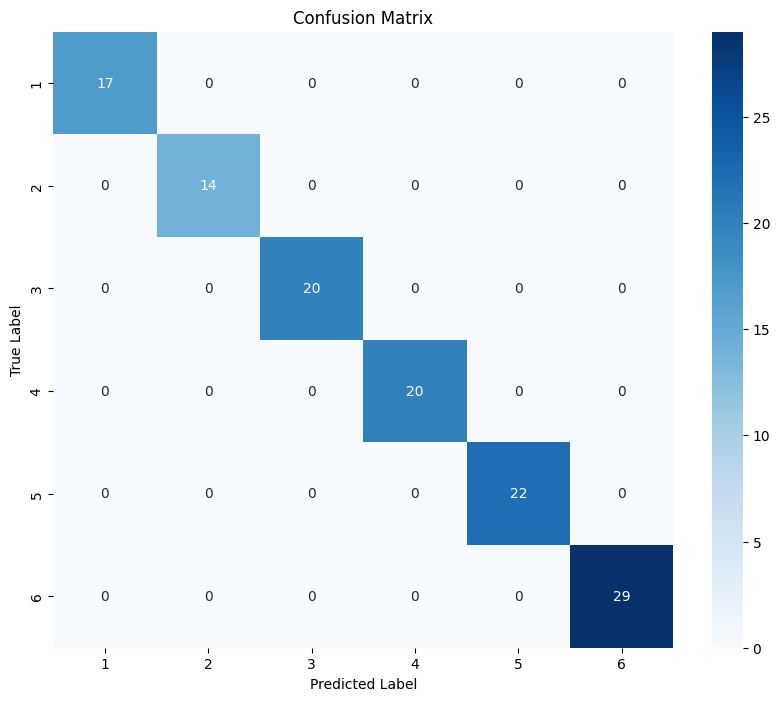

In [18]:
def compute_confusion_matrix(model, dataloader, dataset):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Get actual class names for better visualization
    class_names = dataset.dataset.classes
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    return cm

# Compute and display confusion matrix
cm = compute_confusion_matrix(model, val_loader, val_dataset)

In [19]:
model_info = {
    'class_names': full_dataset.classes,
    'class_to_idx': full_dataset.class_to_idx
}
torch.save(model_info, 'model_checkpoints/model_class_info.pth')